# Retail Sales Analysis — Phase 1: Data Cleaning

This notebook documents the **data cleaning pipeline** for the retail sales dataset. We transform raw data into analysis-ready format through inspection, deduplication, missing value treatment, and feature engineering.

---

## Setup and Imports


In [1]:
import sys
sys.path.append('..')

from src.data_cleaning import * 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

## Load Raw Data

We load the raw retail sales CSV and report the dataset size.


In [2]:
df = load_data("../data/raw/retail_sales.csv")
print(f"Loaded {len(df)} rows from raw dataset.")

Loaded 5020 rows from raw dataset.


## Initial Data Inspection

Before any transformation, we inspect the raw data structure, types, and summary statistics.

### Dataset Preview

In [3]:
display(df.head())

,order_id,order_date,customer_id,customer_age,customer_gender,region,category,product,quantity,unit_price,discount_pct,total_price,payment_method,customer_rating
0,101488,2023-01-01,10359,18.0,Male,South,Books,Comic Book,1,7.73,0,7.73,Debit Card,3.0
1,103674,2023-01-01,10021,30.0,Male,South,Electronics,Tablet,3,435.43,10,1175.67,Debit Card,NaN
2,102259,2023-01-01,10171,48.0,Male,Central,Sports,Tennis Racket,3,64.27,0,192.81,Debit Card,4.0
3,102316,2023-01-01,10500,58.0,Female,East,Electronics,Speaker,3,90.52,0,271.56,PayPal,4.0
4,102442,2023-01-01,10765,18.0,Male,Central,Sports,Dumbbells,3,37.24,15,94.95,Cash,3.0


### Schema and Data Types

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         5020 non-null   int64  
 1   order_date       5020 non-null   object 
 2   customer_id      5020 non-null   int64  
 3   customer_age     4940 non-null   float64
 4   customer_gender  5020 non-null   object 
 5   region           5020 non-null   object 
 6   category         5020 non-null   object 
 7   product          5020 non-null   object 
 8   quantity         5020 non-null   int64  
 9   unit_price       5020 non-null   float64
 10  discount_pct     5020 non-null   int64  
 11  total_price      5020 non-null   float64
 12  payment_method   4980 non-null   object 
 13  customer_rating  4870 non-null   float64
dtypes: float64(4), int64(4), object(6)
memory usage: 549.2+ KB


None

### Summary Statistics

In [5]:
display(df.describe())

,order_id,customer_id,customer_age,quantity,unit_price,discount_pct,total_price,customer_rating
count,5020.000000,5020.000000,4940.000000,5020.000000,5020.000000,5020.000000,5020.000000,4870.000000
mean,102499.980080,10592.374104,37.576113,3.018924,128.549410,7.418327,366.419353,3.773511
std,1444.239214,342.271657,12.264831,1.414439,203.387878,7.553245,680.964498,0.888666
min,100001.000000,10000.000000,18.000000,1.000000,5.920000,0.000000,4.740000,1.000000
25%,101248.750000,10296.750000,29.000000,2.000000,20.105000,0.000000,54.997500,3.000000
50%,102498.500000,10592.500000,37.000000,3.000000,55.850000,5.000000,131.880000,4.000000
75%,103750.250000,10885.000000,46.000000,4.000000,107.650000,15.000000,315.780000,4.000000
max,105000.000000,11199.000000,75.000000,5.000000,1202.470000,20.000000,5523.100000,5.000000


**Observations:**
- The dataset contains `14` columns covering order details, customer demographics, product information, and transaction metadata.
- Several columns show missing values (will be addressed in subsequent steps).
- `order_date` is currently stored as `object` dtype and requires conversion.

## Deduplication

**Why remove duplicates first?**

Duplicates distort statistical summaries, inflate missing value counts, and bias imputation. Removing them **before** any analysis ensures we work with unique observations only.

We identify and remove exact duplicate rows based on all columns.


In [6]:
df, num_dups = remove_duplicates(df)
print(f"Removed {num_dups} duplicate row(s). Dataset now contains {len(df)} unique records.")

Removed 20 duplicate row(s). Dataset now contains 5000 unique records.


## Missing Value Report

After deduplication, we identify columns with missing data.


In [7]:
missing_report = detect_missing_values(df)

if missing_report.empty:
    print("No missing values detected.")
else:
    print("Missing values detected:\n")
    display(missing_report.to_frame(name = "Missing Count"))

Missing values detected:



,Missing Count
customer_rating,150
customer_age,80
payment_method,40


## Missing Value Strategy: Why Row Deletion Is Not Viable

Before deciding on imputation strategies, we evaluate whether **dropping rows with any missing value** is acceptable.

### Missing Value Overlap Analysis

We check how missing values are distributed across the three affected columns.


In [8]:
ca_nans = df["customer_age"].isnull()
cr_nans = df["customer_rating"].isnull()
pm_nans = df["payment_method"].isnull()

ca_cr = ca_nans & cr_nans
ca_pm = ca_nans & pm_nans 
cr_pm = cr_nans & pm_nans 
ca_cr_pm = ca_cr & pm_nans

print("Missing value intersection counts:")
print(f"customer_age ∩ customer_rating: {ca_cr.sum()}")
print(f"customer_age ∩ payment_method: {ca_pm.sum()}")
print(f"customer_rating ∩ payment_method: {cr_pm.sum()}")
print(f"All three columns: {ca_cr_pm.sum()}")

rows_with_any_missing = (ca_nans | cr_nans | pm_nans).sum()
print(f"Using dropna() would remove: {rows_with_any_missing} rows ({rows_with_any_missing * 100 / len(df):.2f}%)")

Missing value intersection counts:
customer_age ∩ customer_rating: 2
customer_age ∩ payment_method: 2
customer_rating ∩ payment_method: 2
All three columns: 0
Using dropna() would remove: 264 rows (5.28%)


**Calculation:**  
$264 = 150 + 80 + 40 - 3 \times 2$

Using the inclusion-exclusion principle, we lose $264$ unique transactions—over **5%** of the dataset.

**Why this matters:**
1. **Transaction data loss:** Each row represents valuable sales information (revenue, product, region). Dropping 5% of transactions distorts aggregate metrics like total revenue and category performance.
2. **Bias introduction:** If missingness correlates with certain customer segments or regions, deletion creates systematic bias.

**Decision:** Row deletion is rejected. We proceed with column-wise imputation.


---

## Imputation Strategy: Column-by-Column Analysis

Having rejected row deletion, we now evaluate each column individually to determine:
1. **Whether the column should be kept** (based on missingness severity)
2. **Which imputation method to use** (median, mode, or group-based)

---

### Impute `customer_age`

#### Missingness Severity


In [9]:
def print_missing_report(
    df: pd.DataFrame,
    column: str,
    missing_count: int,
) -> None:
    """
    Print a formatted missing-value summary for a single column.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset being analyzed.
    column : str
        Name of the column to report on.
    missing_count : int
        Pre-computed count of missing values for the column (from missing_report series).

    Returns
    -------
    None
        Prints formatted output to stdout.
    """
    missing_pct = missing_count * 100 / len(df)
    print(f"'{column}' has {missing_count} missing values ({missing_pct:.2f}% of total rows).")

In [10]:
print_missing_report(df, 'customer_age', missing_report['customer_age'])

'customer_age' has 80 missing values (1.60% of total rows).


**Decision:** With only **1.6% missingness**, dropping the column would discard valuable demographic information. We proceed with imputation.

---

#### Distribution Analysis & Outlier Detection

For numeric columns, both **mean** and **median** are candidates. We use the **IQR method** to detect outliers and assess distribution shape.



In [11]:
def detect_outliers_iqr(series: pd.Series) -> pd.Series:
    """Detect outliers using the Interquartile Range (IQR) method.

    Values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR are flagged
    as outliers. This is a robust method that is not affected by
    the outliers themselves.

    Parameters
    ----------
    series : pd.Series
        Numeric series to check for outliers.

    Returns
    -------
    pd.Series
        Boolean series where True indicates an outlier.
    """
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_fence = Q1 - IQR * 1.5 
    upper_fence = Q3 + IQR * 1.5 
    return (series < lower_fence) | (series > upper_fence)

In [12]:
def plot_distribution_with_outliers(
    df: pd.DataFrame,
    column: str,
    discrete: bool = True,
    kde: bool = True,
    figsize: tuple[float, float] = (10, 6),
) -> None:
    """Plot a boxplot above a histogram on a shared x-axis for outlier review.

    The boxplot exposes the IQR fences and fliers while the aligned histogram
    shows the underlying shape (skew, modes), making it easy to decide between
    mean and median imputation for a numeric column.

    Parameters
    ----------
    df : pd.DataFrame
        Source DataFrame.
    column : str
        Numeric column to visualize (e.g., 'customer_age', 'customer_rating').
    discrete : bool, default=True
        Treat values as discrete integers in the histogram (one bar per value).
    kde : bool, default=True
        Overlay a kernel density estimate on the histogram.
    figsize : tuple of float, default=(10, 6)
        Figure size in inches.

    Returns
    -------
    None
        Renders the figure via plt.show().

    """
    
    fig, (box_ax, hist_ax) = plt.subplots(nrows = 2, ncols = 1,sharex = True, gridspec_kw = {"height_ratios": [0.2, 0.8]}, figsize = figsize)

    sns.boxplot(data = df, x = column, ax = box_ax, width = 0.5, fliersize = 5)
    sns.histplot(data = df, x = column, ax = hist_ax, discrete = discrete, kde = kde)
    
    column = column.replace('_', ' ').title()
    hist_ax.set_xlabel(column, fontsize = 12, fontweight = "bold", labelpad = 10)
    hist_ax.set_ylabel('Frequency / Density', fontsize = 12, fontweight = "bold", labelpad = 10)

    plt.suptitle(f'{column} Distribution & Outlier Analysis', fontsize = 14, fontweight = "bold")
    plt.tight_layout()
    plt.show()

In [13]:
age_outliers = detect_outliers_iqr(df['customer_age'].dropna())
print(f"Detected {age_outliers.sum()} outlier(s) in customer_age.")

Detected 14 outlier(s) in customer_age.


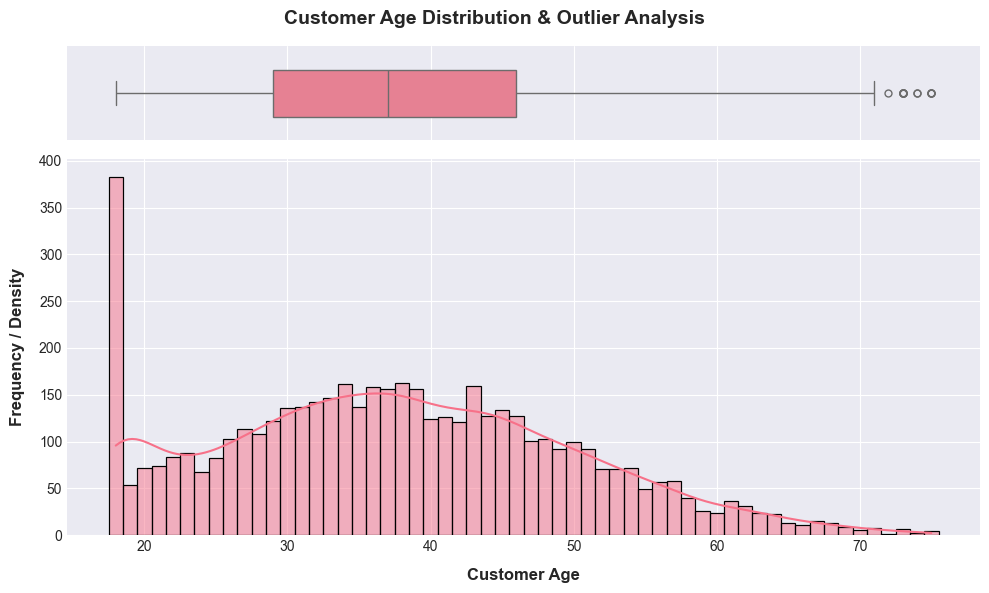

In [14]:
plot_distribution_with_outliers(df, 'customer_age')

**Key Observations:**

1. **Right-skewed distribution:** The histogram shows a long tail toward higher ages, with most values concentrated between 30–40 years. The KDE curve confirms this asymmetry.

2. **Outliers above upper fence:** All 14 detected outliers are **above the upper fence** (visible as individual points in the boxplot), consistent with the right skew.

3. **Mean vs. Median:** The global **median is 37.0**, while the **mean is 37.57**. The mean is pulled higher by the right tail, making **median more robust** for imputation.

4. **Discrete values:** Inspection confirms all ages are **whole numbers** (no fractional values), as expected for age data.

**Conclusion:** Use **median** for imputation due to outlier resistance and distribution skew.


### Group-Based Imputation

While global median (37.0 years) is robust, **group-based imputation** may improve accuracy if customer age varies systematically across features like `product`, `region`, or `category`.

#### Potential Grouping Candidates and Rationale:

**`customer_id`:**  
Ideally, multiple orders from the same customer should share the same age. However, since this is **synthetic data**, we must verify consistency.

**`customer_gender`:**  
Age distributions may differ by gender. Depending on the store's customer base, one gender may be overrepresented in certain age groups, leading to different median ages across genders.

**`region`:**  
Regional demographics vary. A retirement-heavy region may have higher average customer age, while a university town skews younger.

**`category` / `product`:**  
Product preferences correlate with age. Electronics and sports equipment may attract younger customers, while home & kitchen products may appeal to older demographics.

**`payment_method`:**  
Payment preferences may vary by generation—older customers may prefer cash or debit, while younger customers use credit cards and digital wallets like PayPal.

---

#### Testing `customer_id` Consistency


Ideally, multiple orders from the same customer should share the same `customer_age`. However, this dataset is **synthetic**, so we must verify consistency.

**Important context:** The dataset spans **2023–2024**, meaning a customer could legitimately have **at most 2–3 different ages** across transactions (due to birthdays).

Let's check:

In [15]:
age_by_customer = df.groupby('customer_id')['customer_age'].nunique()
age_inconsistent_customers = age_by_customer[age_by_customer > 3].index 
print(f"Customers with inconsistent ages: {len(age_inconsistent_customers)}")

gender_by_customer = df.groupby('customer_id')['customer_gender'].nunique()
gender_inconsistent_customers = gender_by_customer[gender_by_customer > 1].index
print(f"Customers with inconsistent gender: {len(gender_inconsistent_customers)}")

Customers with inconsistent ages: 649
Customers with inconsistent gender: 943


**Finding:** Even with a **lenient threshold of 3 ages**, **649 customers** show age inconsistency, and many customers have inconsistent gender. This confirms the data is **synthetically generated** without preserving real customer identity.

**Conclusion:** Grouping by `customer_id` is **unreliable** and would introduce high imputation error.

---

#### Group-Based Imputation Evaluation

We use a **two-stage evaluation process** to determine whether group-based imputation is justified:



**Stage 1: Dynamic Maximum Deviation Screening** 

Calculate the **maximum percentage deviation** of group medians from the global median. To respect the mathematical scale of different data types, the screening threshold is **applied dynamically based on the target feature being imputed**:

* **`customer_age` (Continuous Scale):** Uses a **10% threshold** (requiring a group median shift of $\ge 3.7$ years) to filter out negligible demographic variance.
* **`customer_rating` (Discrete 1.0–5.0 Scale):** Uses a **25% threshold** (requiring a group median shift of $\ge 1.0$ full star on a 4.0 global baseline) to isolate major shifts in customer sentiment.

- **Pass (Group Deviation $\ge$ Dynamic Threshold):** Proceed to Stage 2 (holdout test).
- **Fail (Group Deviation $<$ Dynamic Threshold):** Use the global median (grouping adds pipeline complexity without statistical benefit).

**Stage 2: Holdout Imputation Test** 

For features that pass Stage 1, we simulate the imputation process on an isolated 30% validation holdout set to measure actual predictive lift against the global baseline:

1. Mask 30% of known target values to create an isolated test set.
2. Compute group-based statistics (medians for numeric targets, modes for categorical targets) strictly using the remaining 70% training set.
3. Impute the masked test values using both the global baseline and group-based mapping strategies.
4. Compare performance by calculating **Mean Absolute Error (MAE)** for numeric targets or **Classification Accuracy** for categorical targets.

To justify the added pipeline complexity of tracking and maintaining group-based data structures, the performance improvement ($\text{MAE}_{\text{global}} - \text{MAE}_{\text{group}}$ or $\text{Accuracy}_{\text{group}} - \text{Accuracy}_{\text{global}}$) must pass a **dynamic, feature-dependent threshold**:

* **`customer_age`:** MAE reduction $\ge 0.5$ years (or an error drop of $\ge 5\%$).
* **`customer_rating`:** MAE reduction $\ge 0.15$ stars (accounting for the tight 1.0–5.0 scale).
* **`payment_method`:** Absolute Classification Accuracy increase $\ge 5$ percentage points.

- **Pass (Improvement $\ge$ Dynamic Threshold):** Implement the group-based imputation pipeline for the given feature.
- **Fail (Improvement $<$ Dynamic Threshold):** Fall back to the global statistic (the localized predictive lift does not justify the added engineering complexity).


---

**Stage 1: Maximum Deviation Analysis**

In [16]:
def compute_max_deviations(
    df: pd.DataFrame,
    target_column: str,
    grouping_features: list[str],
) -> dict[str, float]:
    """
    Compute maximum percentage deviation of group medians from global median.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_column : str
        Column to analyze (e.g., 'customer_age', 'customer_rating').
    grouping_features : list[str]
        List of features to test for group-based imputation.
 
    Returns
    -------
    dict[str, float]
        Dictionary mapping feature name to maximum deviation percentage.
    """
    ind = df[~df[target_column].isnull()].index
    global_median = df[target_column].median()
    max_deviations = {}
    for feature in grouping_features:
        max_deviations[feature] = ((((df.loc[ind].groupby(feature, observed = True)[target_column].median()) - global_median).abs()) * 100 / global_median).max()
    return max_deviations

In [17]:
def plot_max_deviations(
    max_deviations: dict[str, float],
    threshold: float,
    figsize: tuple[int, int] = (8, 5)
) -> None:
    """
    Visualize maximum deviation percentages with threshold line.
    
    Parameters
    ----------
    features_max_deviation_pct : dict[str, float]
        Dictionary mapping feature names to deviation percentages.
    threshold : float
        Deviation threshold (%). Features above this proceed to Stage 2.
    figsize : tuple[int, int], default=(8, 5)
        Figure size (width, height) in inches.
    
    Returns
    -------
    None
        Displays the plot via plt.show().
        
    """
    max_deviations = pd.DataFrame({'feature' : max_deviations.keys(),
                        'max_deviation_pct' : max_deviations.values()})
    palette = max_deviations['max_deviation_pct'].apply(
        lambda pct: "#e74c3c" if pct >= threshold else "#3498db").tolist()
    
    fig, ax = plt.subplots(figsize = figsize)
    sns.barplot(data = max_deviations, x = 'feature', y = 'max_deviation_pct', ax = ax,
                hue = 'feature', palette = palette, legend = False, edgecolor = 'black', linewidth = 0.7 )
    for i in range(len(max_deviations)):
        pct = max_deviations.loc[i, "max_deviation_pct"]
        ax.text(x = i, y = pct + 0.3, s = f"{pct:.1f}%", fontsize = 10, ha = 'center', va = 'bottom')
    ax.axhline(threshold, color = 'red', linestyle = '--', linewidth = 1.5, label = f"{threshold:.0f}% Threshold")
    
    ax.set_xlabel('Grouping Feature', fontweight = 'bold', fontsize = 12, labelpad = 10)
    ax.set_ylabel('Max Deviation (%)', fontweight = 'bold', fontsize = 12, labelpad = 10)
    ax.set_title('Stage 1: Maximum Group Deviation from Global Median', fontweight = 'bold', fontsize = 14, pad = 15)
    ax.set_ylim(0, max(max_deviations['max_deviation_pct'].max(), threshold) + 2)
    ax.legend(loc = 'upper right')

    plt.tight_layout()
    plt.show()

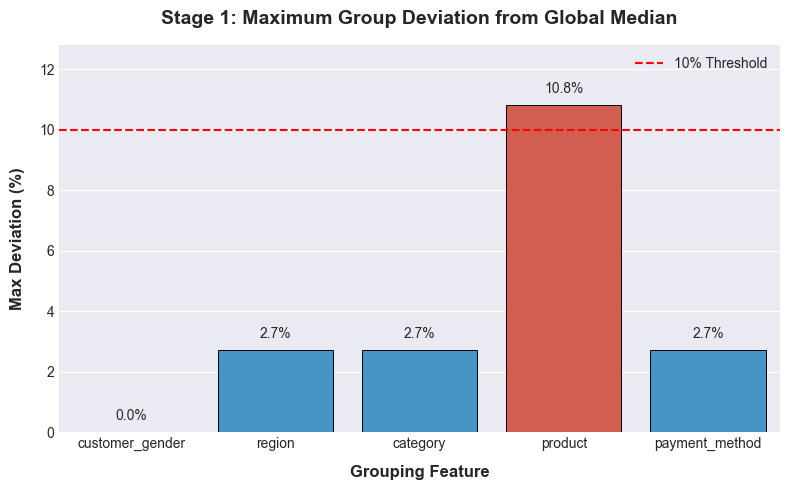

In [18]:
age_max_deviations = compute_max_deviations(df, 'customer_age', 
                        ['customer_gender', 'region', 'category', 'product', 'payment_method'])
plot_max_deviations(age_max_deviations, 10.0)

**Stage 1 Results: Maximum Group Deviation Analysis**

The bar chart shows the maximum percentage deviation of group medians from the global median (37.0 years) across five grouping features:

| Feature             | Max Deviation | Status          |
|---------------------|---------------|-----------------|
| `customer_gender`   | 0.0%          | ✓ Below threshold |
| `region`            | 2.7%          | ✓ Below threshold |
| `category`          | 2.7%          | ✓ Below threshold |
| `payment_method`    | 2.7%          | ✓ Below threshold |
| `product`           | **10.8%**     | **EXCEEDS threshold** |

**Key Observations:**

1. **`product` is the only feature that exceeds the 10% threshold** (equivalent to ~3.7 years deviation), indicating meaningful age variation across product types.

2. **`customer_gender` shows zero deviation**, meaning both male and female customers have identical median ages (37.0 years). Group-based imputation would provide no benefit.

3. **`region`, `category`, and `payment_method` show identical 2.7% deviations**, well below the threshold. These small differences (~1 year) are not statistically meaningful for imputation purposes.

**Decision:** Only **`product`** proceeds to **Stage 2 (Holdout Imputation Test)** to validate whether group-based imputation improves predictive accuracy over the global median.

---
**Stage 2: Holdout Imputation Test**

In [19]:
def holdout_imputation_test(
    df: pd.DataFrame,
    target_column: str,
    grouping_features: list[str],
    threshold: float,
    test_size: float = 0.30,
    statistic: str = "median",
    metric: str = "mae",
    random_state: int = 42,
) -> pd.DataFrame:
    """Stage 2 holdout test comparing global vs. group-based imputation lift.

    Masks a random holdout of known target values, recomputes imputation
    statistics from the remaining training portion only, and measures the
    predictive lift of each candidate grouping feature against the global
    baseline. Numeric targets are scored with Mean Absolute Error (MAE) and
    categorical targets with classification accuracy. Only features whose
    improvement meets the threshold are retained, justifying the added
    pipeline complexity of group-based structures.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing the target column and grouping features.
    target_column : str
        Column to impute (e.g., 'customer_age', 'customer_rating', 'payment_method').
    grouping_features : list of str
        Candidate features to test for group-based imputation (e.g., ['product']).
    threshold : float
        Minimum required improvement over the global baseline for a feature to pass:
        - For MAE: global_MAE - group_MAE must be >= threshold (error reduction).
        - For accuracy: group_accuracy - global_accuracy must be >= threshold.
    test_size : float, default=0.30
        Proportion of known target values to mask as the holdout set.
    statistic : {"median", "mode"}, default="median"
        Summary statistic used for imputation:
        - "median": For numeric targets (e.g., customer_age, customer_rating).
        - "mode": For categorical targets (e.g., payment_method).
    metric : {"mae", "accuracy"}, default="mae"
        Evaluation metric:
        - "mae": Mean Absolute Error for numeric targets (lower is better).
        - "accuracy": Proportion of correct predictions for categorical targets.
    random_state : int, default=42
        Random seed for the holdout split, for reproducibility.

    Returns
    -------
    pd.DataFrame
        A summary DataFrame containing the evaluation results for each tested 
        grouping feature. Rows are sorted best-first (ascending order for MAE 
        or descending order for accuracy).

    """

    data_idx = df[~df[target_column].isnull()].index
    test_idx = df.loc[data_idx].sample(frac = test_size, random_state = random_state).index
    features_eval = {}
    for feature in grouping_features + [target_column]:
        data = df.loc[data_idx].copy()
        data.loc[test_idx, target_column] = np.nan
        if feature == target_column:
            data = impute_column(data, target_column, statistic)
        else:
            data = impute_column(data, target_column, statistic, feature)
        
        if metric == "mae":
            features_eval[feature] = (data.loc[test_idx, target_column] - df.loc[test_idx, target_column]).abs().sum() / len(test_idx)
        elif metric == "accuracy":
            features_eval[feature] = (data.loc[test_idx, target_column] == df.loc[test_idx, target_column]).mean()
    
    global_eval = features_eval.pop(target_column)
    print(f'{metric.upper()} Score of {target_column} imputation using global {statistic}: {global_eval}')
    
    features_eval = pd.DataFrame({'feature' : features_eval.keys(), f'{metric}' : features_eval.values()})
    if metric == 'mae':
        features_eval["improvement"] = global_eval - features_eval['mae']
        features_eval["passes"] = features_eval["improvement"] >= threshold
        features_eval = features_eval.sort_values('mae')
    elif metric == 'accuracy':
        features_eval["improvement"] = features_eval['accuracy'] - global_eval
        features_eval["passes"] = features_eval["improvement"] >= threshold
        features_eval = features_eval.sort_values('accuracy', ascending = False)
        
    return features_eval

In [20]:
age_features_eval = holdout_imputation_test(df, 'customer_age', ['product'], 0.5)
display(age_features_eval)

MAE Score of customer_age imputation using global median: 9.847560975609756


,feature,mae,improvement,passes
0,product,10.027439,-0.179878,False


### `customer_age` — Group-based imputation rejected

We tested `product` as a grouping feature for imputing `customer_age` on a 30%
holdout, scoring with MAE (lower is better):

| Strategy            | MAE     |
|---------------------|---------|
| Global median       | 9.8476  |
| Grouped by `product`| 10.0274 |

Improvement $= \text{MAE}_{\text{global}} - \text{MAE}_{\text{group}}
= 9.8476 - 10.0274 = -0.1798$ years.

Grouping by `product` did not reduce the error; it actually **increased** MAE
by roughly $0.18$ years. The result is negative, so it falls well short of the
$\ge 0.5$ year threshold required to justify the extra pipeline complexity.

This makes intuitive sense: a customer's age has no real dependence on which
product they bought, so per-product medians just add noise from small,
unrepresentative groups. We therefore **fall back to the global median** for
imputing `customer_age`.


In [21]:
df = impute_column(df, 'customer_age')

### Impute `customer_rating`

#### Missingness Severity

In [22]:
print_missing_report(df, 'customer_rating', missing_report['customer_rating'])

'customer_rating' has 150 missing values (3.00% of total rows).


**Decision:** 3% missingness is low enough that dropping the
column would throw away genuine satisfaction signal, which is one of the few
behavioral measures we have. We keep the column and proceed with imputation.

#### Median vs. Mean
`customer_rating` is a discrete integer score on a fixed 1.0–5.0 scale, the same
integer-valued situation we had with `customer_age`. To choose between median
and mean we check for outliers with the IQR method.
A skewed distribution or any outliers push us toward the **median**, which is
robust to both and stays on-scale for an integer rating.

In [23]:
rating_outliers = detect_outliers_iqr(df['customer_rating'].dropna())
print(f"Detected {rating_outliers.sum()} outlier(s) in customer_rating.")

Detected 37 outlier(s) in customer_rating.


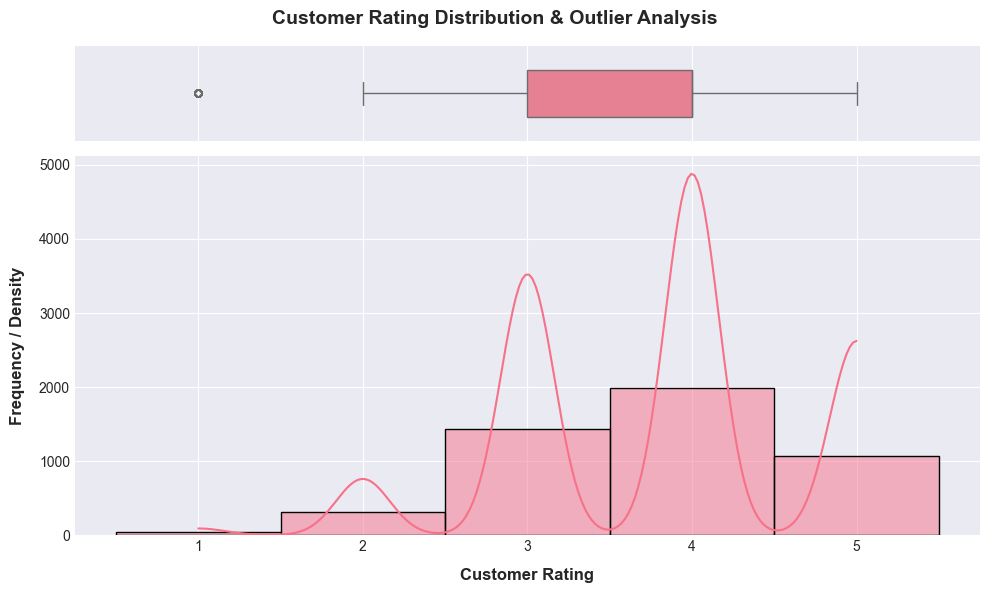

In [24]:
plot_distribution_with_outliers(df, 'customer_rating')

#### Distribution & Outlier Observation

The boxplot and histogram tell a clear story for `customer_rating`:

- **Left-skewed distribution.** The bulk of ratings sit at 3, 4, and 5, with a
  long thin tail reaching down toward 1. The mass is concentrated on the high
  end and trails off to the left.
- **Outliers below the lower fence.** The IQR method flags **37 outliers**, all
  of them *below* the lower fence (the lone cluster at rating 1). There are no
  high-side outliers, which is consistent with the left skew.
- **Integer-only scale.** Every rating is a whole number on a fixed 1–5 scale;
  no fractional values exist in the data.

Because the distribution is skewed and carries a block of low-end outliers, the
**mean is dragged downward** (mean = **3.77**) below where most customers
actually rate. The **median = 4.0** is robust to those 37 low outliers and lands
squarely on a real, on-scale rating value. Since the data is integer-only, an
imputed 4.0 matches the nature of the column exactly, whereas 3.77 is a value no
customer could ever give. We therefore choose the **median** for imputation.


### Group-Based Imputation

While the global median is robust, **group-based imputation** may improve
accuracy if `customer_rating` varies systematically across features like
`customer_id`, `customer_gender`, `region`, `category`, `quantity`, `discount_pct`, or
`payment_method`.

#### Potential Grouping Candidates and Rationale:

**`customer_id`:**  
A given customer often rates consistently, generous raters stay generous, harsh
ones stay harsh. Repeat orders from the same id should cluster around a personal
baseline.

**`customer_gender`:**  
Rating behavior can differ by gender if one group is systematically more
critical or more lenient, shifting the median rating between groups.

**`region`:**  
Service quality, delivery speed, and expectations vary by region. A
well-served region may post higher ratings while an underserved one trends lower.

**`category` / `product`:**  
Satisfaction is product-driven. Reliable categories (e.g., books) may earn
consistently high ratings, while failure-prone ones (e.g., electronics) attract
more low scores, pulling per-category medians apart.

**`quantity`:**  
Bulk buyers may be more committed or experienced customers, potentially rating
differently than one-off purchasers, though this link is weaker and worth testing.

**`discount_pct`:**  
Discounts can lift perceived value and ratings, or signal clearance of
lower-quality stock that disappoints. Either way the relationship is plausible
enough to test.

**`payment_method`:**  
Payment choice can act as a proxy for the checkout and fulfillment experience.
Frictionless methods (e.g., saved digital wallets) may correlate with smoother
transactions and higher satisfaction, while methods tied to slower or
higher-risk flows (e.g., cash on delivery) can attract more disputes and lower
ratings.

---

**Stage 1: Maximum Deviation Analysis**

**A note on `quantity` and `discount_pct`:**  
Although both are stored as numbers, their value counts show only a handful of
discrete levels:

- `quantity` → `{1, 2, 3, 4, 5}`, each appearing ~1,000 times.
- `discount_pct` → `{0, 5, 10, 15, 20}`, with 0 dominating (~2,000 rows) and the
  rest in the 700–800 range.

There are no continuous in-between values, every observation lands on one of a
few fixed levels with hundreds of rows behind it. This is exactly the structure
of a **categorical code**, not a continuous measurement. Each level forms a
dense, well-populated group, so we can safely use `quantity` and `discount_pct`
as grouping features in the deviation analysis without any binning.

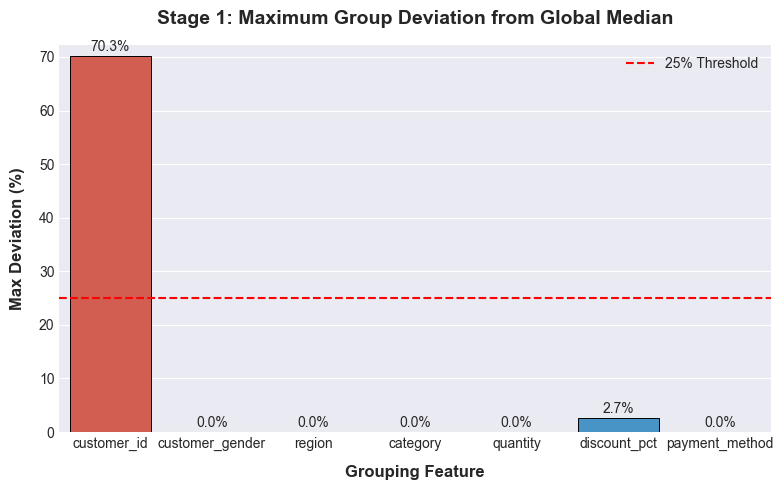

In [25]:
age_max_deviations = compute_max_deviations(df, 'customer_age', 
                        ['customer_id', 'customer_gender', 'region', 'category', 'quantity', 'discount_pct', 'payment_method'])
plot_max_deviations(age_max_deviations, 25.0)

**Stage 1 Results: Maximum Group Deviation Analysis**

The bar chart shows the maximum percentage deviation of group medians from the
global median (**4.0**) across the grouping features. Given the compressed 1–5
scale, a single one-point shift already equals a 25% deviation, so we set the
threshold at **25%**:

| Feature             | Max Deviation | Status              |
|---------------------|---------------|---------------------|
| `customer_gender`   | 0.0%          | ✓ Below threshold   |
| `region`            | 0.0%          | ✓ Below threshold   |
| `category`          | 0.0%          | ✓ Below threshold   |
| `quantity`          | 0.0%          | ✓ Below threshold   |
| `payment_method`    | 0.0%          | ✓ Below threshold   |
| `discount_pct`      | 2.7%          | ✓ Below threshold   |
| `customer_id`       | **70.0%**     | **EXCEEDS threshold** |

**Key Observations:**

1. **`customer_id` is the only feature that clears the 25% threshold**, and it
   does so dramatically at 70%. Individual customers rate around very different
   personal baselines, so per-customer medians diverge sharply from the global
   4.0.

2. **`customer_gender`, `region`, `category`, `quantity`, and `payment_method`
   all show 0% deviation** — every group's median equals the global median of
   4.0. Grouping on any of these would just reproduce the global value, offering
   no benefit.

3. **`discount_pct` shows a tiny 2.7% deviation**, far below the threshold and
   not meaningful for imputation.

**Decision:** Only **`customer_id`** proceeds to **Stage 2 (Holdout Imputation Test)**. 
Because `customer_rating` is treated as a numerical continuous target on a fixed 1–5 scale, Stage 2 is evaluated using **Mean Absolute Error (MAE)**. A dynamic threshold of **$\ge 0.15$ stars in MAE reduction** is required to justify the added tracking complexity of the group-based pipeline.

---

**Stage 2: Holdout Imputation Test**

In [26]:
rating_features_eval = holdout_imputation_test(df, 'customer_rating', ['customer_id'], 0.15)
display(rating_features_eval)

MAE Score of customer_rating imputation using global median: 0.6467353951890035


,feature,mae,improvement,passes
0,customer_id,0.830584,-0.183849,False


### `customer_rating` — Group-based imputation rejected

We tested `customer_id` as a grouping feature for imputing `customer_rating` on a 30% holdout, scoring with MAE (lower is better):

| Strategy                 | MAE    |
|--------------------------|--------|
| Global median            | 0.6467 |
| Grouped by `customer_id` | 0.8306 |

Improvement $= \text{MAE}_{\text{global}} - \text{MAE}_{\text{group}} = 0.6467 - 0.8306 = -0.1838$ stars.

Grouping by `customer_id` failed to reduce the predictive error; it actually **increased** MAE by roughly $0.18$ stars. The result represents a significant performance degradation and completely misses our dynamic threshold of a $\ge 0.15$ star reduction. We therefore **fall back to the global median** for imputing `customer_rating`.

In [27]:
df = impute_column(df, 'customer_rating')

### Restoring Integer Types After Imputation

With `customer_age` and `customer_rating` now fully imputed, both columns are
complete but still carry a `float64` dtype — a side effect of pandas promoting
integer columns to float the moment a single `NaN` appears.

Now that no missing values remain, we restore their natural **`int64`** type
using the `cast_clean_dtype` helper. This is safe because every imputed value is
already whole: ages were filled with the global median (a whole year) and
ratings with the global median of 4.0 (an on-scale integer score). The cast
introduces no rounding or information loss — it simply removes the trailing
`.0`, shrinks memory, and makes the columns reflect their true nature as discrete
counts (years) and ordinal scores (1–5 stars).


In [28]:
df = cast_clean_dtypes(df, ['customer_age', 'customer_rating'])

### Impute `payment_method`

#### Assessing Missingness: Is Dropping `payment_method` an Option?

Before imputing, we check whether removing the column is justified by the
severity of its missingness.

In [29]:
print_missing_report(df, 'payment_method', missing_report['payment_method'])

'payment_method' has 40 missing values (0.80% of total rows).


`payment_method` is missing in only **0.8%** of rows. This is far below any
threshold that would warrant dropping the column — over 99% of the data is
intact and informative. `payment_method` is a core behavioral attribute, so
discarding an almost-complete column to avoid imputing a tiny fraction
of rows would trade a huge loss of analytical value for a negligible gain.

**Decision:** We **keep** `payment_method` and impute the missing 0.8% rather
than drop it.

### Baseline Mode Imputation vs. Group-Based Strategies

Due to its categorical identity, the baseline method for imputing missing values in `payment_method` is to utilize the **Global Mode (the most frequent value)** across the entire dataset. In this case, that baseline is `Credit Card`, which accounts for roughly 38% of all transactions. 

While substituting every missing value with this dominant class is highly robust and straightforward, it ignores the unique purchasing contexts of individual buyers. Before relying blindly on a single global default, it is highly valuable to evaluate **group-based imputation**. By conditioning on localized structural drivers, we can determine whether specific consumer subsets deviate significantly from the baseline and exhibit distinct, alternative payment preferences.

#### Potential Grouping Candidates for `payment_method`

**`customer_id`:**  
Payment choice is one of the stickiest personal habits — a given customer tends
to reuse the same saved card or wallet across orders. Per-customer modes should
therefore be highly concentrated, making `customer_id` the strongest a-priori
candidate for predicting a missing payment method.

**`age_group`:**  
Payment preference correlates with generation and life stage. Younger cohorts
lean toward digital wallets and mobile pay, while older cohorts skew toward
credit cards or cash-on-delivery. Binning age into groups should expose distinct
modal payment classes per segment.

**`price_group`:**  
Order value drives payment choice. Low-value orders are often paid with wallets
or cash, while high-value orders push customers toward credit cards or
installment-friendly methods (financing comfort, rewards, fraud protection).
Bucketing the order amount should separate these behavioral regimes.

**`region`:**  
Payment ecosystems are deeply geographic. Card penetration, cash-on-delivery
norms, and locally dominant wallets differ markedly across regions, so a
customer's region is a plausible proxy for their available and preferred payment
rails.

**`category`:**  
high-ticket categories (electronics, appliances) tend to
attract cards and installment plans, while low-ticket impulse categories skew
toward wallets and cash. The signal is weaker than the above but worth testing.


While each of these candidates presents a compelling behavioral rationale, we must transition from logical hypotheses to empirical validation. To systematically determine which—if any—of these grouping features provide a mathematically sound and production-justified improvement over our simple global baseline, we apply a specialized validation framework. 


### `payment_method` — Two-Stage Categorical Imputation Framework

Because `payment_method` is a categorical feature with 5 discrete classes, the
traditional numeric deviations (using medians) are structurally invalid. Instead,
the pipeline adapts to use **mode-based frequency matching** and **classification
accuracy** tracking.

#### Stage 1: Mode-Based Relative Frequency Shift (Feature Selection)

Instead of measuring a raw numeric median deviation, we track how the distribution of the target class shifts across different slices of a grouping feature compared to the global baseline. A feature successfully passes this selection stage if it satisfies **at least one** of the following two criteria in any of its sub-groups:

1. **Mode Cardinality Flip:** The local mode within at least one group switches completely to an entirely different payment method (e.g., a group's most frequent choice shifts from `Credit Card` to `PayPal` or `Cash`).
2. **Baseline Frequency Spike:** The local mode remains `Credit Card`, but its localized concentration experiences a **Relative Frequency Shift of $\ge 15\%$** compared to the global baseline (e.g., jumping from the global baseline of ~38% to over 53% within that specific group slice).

This dual-trigger verification ensures that the grouping feature divides the dataset into segments with distinct, highly localized payment habits before proceeding to the holdout test.

#### Stage 2: Holdout Accuracy Lift Validation (Complexity Justification)

For features passing Stage 1, we simulate the categorical imputation pipeline on
an isolated 30% holdout validation partition:

1. Mask 30% of known `payment_method` entries to serve as the test set.
2. Compute the local mode for each group using strictly the remaining 70%
   training slice.
3. Impute the masked test values using both the global mode fallback baseline
   (`Credit Card`) and the group-specific mode mappings.
4. Score performance using **classification accuracy** (higher is better).

To justify the engineering and maintenance complexity of tracking multi-class
grouping matrices in production, the group-based strategy must clear a **dynamic
accuracy lift threshold of $\ge 5.00$ percentage points** over the global
baseline accuracy:

$$\text{Improvement} = \text{Accuracy}_{\text{group}} - \text{Accuracy}_{\text{global}} \ge 0.05$$

- **Pass:** Adopt the group-mode mapping architecture for `payment_method`.
- **Fail:** Fall back to the global baseline mode (`Credit Card`) for all missing
  data.


---

### Feature Engineering: `age_group` and `price_group`

we derive two new grouping features from the existing numeric columns:

**`age_group`:**  
Bins `customer_age` into five life-stage cohorts using fixed, interpretable
thresholds: 18–25 (young/digital-first), 26–35 (early career), 36–50 (established),
51–65 (mature), and 65+ (retirees). These boundaries align with generational
payment adoption patterns rather than statistical quartiles.

**`price_group`:**  
Bins `price` into five spending tiers using quantile-based cuts: Budget, Low, Mid,
High, and Premium (top decile). Because the price distribution is heavily
right-skewed (mean $366.78$ vs. median $131.79$), quantile binning ensures
balanced group sizes and isolates the high-value tail where payment behavior
(installments, cards) plausibly diverges.

Both features are immediately usable as categorical grouping keys in Stage 1
mode-shift analysis.


In [30]:
df['age_group'] = pd.cut(df['customer_age'], bins = [17, 25, 35, 50, 65, 75], 
                         labels = ["18-25", "26-35", "36-50", "51-65", "65+"])

In [31]:
df['price_group'] = pd.qcut(df['total_price'], q = [0, 0.25, 0.5, 0.75, 0.9, 1.0],
                           labels = ["Budget", "Low", "Mid", "High", "Premium"])

**Stage 1: Mode-Based Feature Selection**

In [32]:
def mode_based_feature_selection(
    df: pd.DataFrame,
    target_column: str,
    grouping_features: list[str],
    threshold: float = 0.15,
) -> pd.DataFrame:
    """
    Stage 1: Mode-Based Relative Frequency Shift for categorical imputation.

    Evaluates candidate grouping features to determine if they create sub-groups
    with distinct payment class distributions. A feature passes if at least one
    of its groups satisfies either:
      1. Mode Cardinality Flip: Local mode differs from the global mode.
      2. Baseline Frequency Spike: Local mode matches global but its relative
         frequency exceeds the global baseline by >= threshold.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset containing the target column and grouping features.
    target_column : str
        The categorical column to impute (e.g., 'payment_method').
    grouping_features : list[str]
        Candidate features to test as grouping keys.
    threshold : float, default=0.15
        Minimum relative frequency shift required for a same-mode group to pass.

    Returns
    -------
    pd.DataFrame
        A two-column DataFrame with 'feature' names and 'is_selected' boolean
        indicating which features passed Stage 1 and should proceed to holdout.
    """
    
    global_mode = df[target_column].mode()[0]
    non_missing_idx = df[~df[target_column].isnull()].index
    global_mode_rf = (df.loc[non_missing_idx, target_column] == global_mode).mean()
    features_pass = {}

    def group_evaluation(group):
        local_mode = group.mode()[0]
        return (local_mode != global_mode) or (((group == local_mode).mean() - global_mode_rf) >= threshold)
            
    for feature in grouping_features:
        grouped_mode = df.loc[non_missing_idx].groupby(feature, observed = True)[target_column].apply(
            lambda x: group_evaluation(x))
        features_pass[feature] = grouped_mode.any()
            
    return pd.DataFrame({'feature' : features_pass.keys(), 'is_selected' : features_pass.values()})
        

In [33]:
payment_method_features_pass = mode_based_feature_selection(df, 'payment_method',
                                ['customer_id', 'age_group', 'price_group', 'region', 'category'], 0.15)
display(payment_method_features_pass)

,feature,is_selected
0,customer_id,True
1,age_group,False
2,price_group,False
3,region,False
4,category,False


### Stage 1 Results: Feature Selection for `payment_method`

Only **`customer_id`** passed Stage 1, meeting at least one of the two selection
criteria (mode flip or $\ge 15\%$ frequency spike) in one or more of its groups.
All other features — `age_group`, `price_group`, `region`, and `category` —
failed to produce sub-groups with sufficiently distinct payment-method
distributions and are therefore dropped from further analysis.

**Next step:** `customer_id` proceeds to Stage 2 holdout imputation validation
to determine whether its observed local modes generalize and justify the
engineering overhead of group-based imputation.

**Cleanup:** The engineered features `age_group` and `price_group`, having failed
Stage 1, are removed from the DataFrame to keep the schema lean and avoid
carrying unused derivative columns forward.


In [34]:
df = df.drop(columns = ['price_group', 'age_group'])



--- 

**Stage 2: Holdout Imputation Test**

In [35]:
payment_method_features_eval = holdout_imputation_test(df, 'payment_method', ['customer_id'],
                                0.05, 0.3, 'mode', 'accuracy' )
display(payment_method_features_eval)

ACCURACY Score of payment_method imputation using global mode: 0.3595430107526882


,feature,accuracy,improvement,passes
0,customer_id,0.268145,-0.091398,False


### Stage 2 Holdout Results: `customer_id` Imputation Test

Despite passing Stage 1's mode-shift filter, **`customer_id` failed the holdout
validation**. Group-based imputation by customer achieved only **26.8% accuracy**
on the masked test set — **9.1 percentage points worse** than the global-mode
baseline of **36.0%**.

This counterintuitive result stems from severe data sparsity: most customers
appear only once or twice in the dataset, leaving insufficient training data to
reliably estimate per-customer payment modes. The local modes derived from such
small samples are noisy and overfit to coincidental choices, degrading
generalization performance.

**Decision:** We reject group-based imputation for `payment_method` and fall back
to the **global mode (`Credit Card`)** for all 0.8% of missing values. This
simpler strategy maximizes accuracy and avoids the complexity cost of maintaining
a fragile customer-level mode mapping.


In [36]:
df = impute_column(df, 'payment_method', 'mode')

### Date Parsing and Temporal Feature Engineering

The `order_date` column, currently stored as a string, is parsed into a proper
`datetime64[ns]` type to enable time-based analysis. From this parsed timestamp,
we derive two new temporal grouping features:

- **`order_month`:** Extracts the month to capture seasonal purchasing and
  payment trends.
- **`order_weekday`:** Extracts the day of the week to expose
  weekday vs. weekend behavioral patterns.

Both features are retained as categorical columns for downstream segmentation.


In [37]:
df = parse_dates_and_create_features(df)

### Validation and Persistence

With all imputations, type corrections, and feature engineering complete, the
cleaned dataset undergoes a final validation pass to confirm:

- No remaining missing values across all columns.
- All data types are correct and production-ready (`int64` for discrete counts,
  `category` for nominal features, `datetime64[ns]` for timestamps).
- All engineered features are present and well-formed.

The validated DataFrame is then persisted to `../data/processed/retail_sales.csv`,
marking the completion of Phase 1 and establishing the authoritative clean
dataset for all downstream analysis and modeling.


In [38]:
validate_clean_data(df)
save_clean_data(df)